# DHL Pickup Optimization: Customer Segmentation using RFM + K-Means Clustering
**Topic: Unsupervised Learning – Clustering (K-Means)**


In [ ]:
# --- Import Libraries ---
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
# --- Load the Dataset ---
# This dataset simulates DHL customer pickup transactions
url = "https://raw.githubusercontent.com/saikisri97/Optimisation/master/For_AI_Lecture/data/K-means_dataset.csv"
df = pd.read_csv(url)
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,Germany
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,Germany
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,Germany
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,Germany
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,Germany


In [4]:
# --- Preprocessing ---
# Remove transactions with missing customer IDs
df = df.dropna(subset=['CustomerID'])

# Convert InvoiceDate to proper datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Optional: Add TotalPrice column for clarity
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Set a snapshot date for Recency calculation
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [5]:
# --- RFM Feature Engineering ---
# RFM = Recency, Frequency, Monetary
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalPrice': 'sum'                                       # Monetary
}).reset_index()

# Rename columns for clarity
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [9]:
#---Filtering for outliers as they impact the means ----
# Example for Monetary
Q1 = rfm['Monetary'].quantile(0.25)
Q3 = rfm['Monetary'].quantile(0.75)
IQR = Q3 - Q1
rfm = rfm[(rfm['Monetary'] >= Q1 - 1.5 * IQR) & (rfm['Monetary'] <= Q3 + 1.5 * IQR)]


In [10]:
# --- Standardize Features ---
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [11]:
# --- Apply K-Means Clustering ---
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

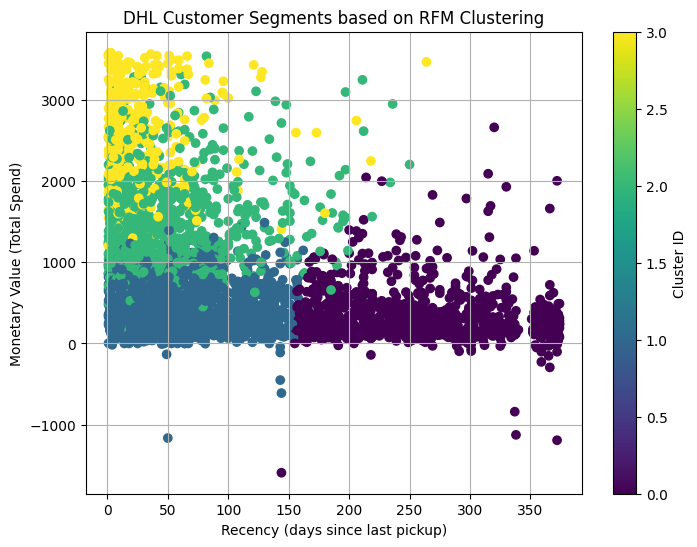

In [12]:
# --- Visualize the Clusters ---
plt.figure(figsize=(8, 6))
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis')
plt.title("DHL Customer Segments based on RFM Clustering")
plt.xlabel("Recency (days since last pickup)")
plt.ylabel("Monetary Value (Total Spend)")
plt.grid(True)
plt.colorbar(label='Cluster ID')
plt.show()

### Optional Enhancements for Learners
- Try the Elbow Method to find the optimal number of clusters
- Use Silhouette Score to validate clustering performance
- Perform dimensionality reduction (e.g., PCA) for better visualization

### Real-World Use Case
**DHL can use this segmentation to:**
- Prioritize high-value frequent customers for express pickups
- Identify churn-risk customers (high recency, low frequency)
- Tailor promotions or loyalty programs to specific segments